# Laboratory Day 5b: Houph transformation


**Exercise 2.1 (30 points)**
Implement Hough Transformation by yourself and apply it to image "airplane.png" to detect the white lines on the aircraft runway.

HT consists of the following 3 steps:

(1) Edge detection. It is recommended to call Canny edge detector, cv2.Canny(). After step (1), please display the image of all detected edge points. (5 points)

(2) Transformation the detected edge points into their parameter space. Please implement a function for this step, e.g. hough_transformation_line(image, delta_r, delta_phi) -> accumulator matrix. delta_r and delta_phi are small distances for discretization of parameter space. After step (2), please display the accumulator matrix, when it is applied to the edge image of "airplance.png". (15 points)


(3) Find out the local maxima in the accumulator matrix manually. These local maxima refer to the detected lines. Please display the represented lines of these maxima in an image (for each detected $r$ and $\phi$, convert it back to a line). To check your results, the position of these lines should be roughly the same as the white lines on the aircraft runway. (10 points)




Edge Detection Setup and Canny Application: First, let's load the airplane.png image. Remember that cv2.Canny() typically works best on grayscale images, so you might need to convert your image first. Consider what parameters (threshold1, threshold2, apertureSize) for cv2.Canny() are most appropriate for this image to effectively highlight the white lines on the runway. What are these parameters controlling, and how might they influence the detected edges? After applying Canny, display the resulting binary edge image. What does a good edge image look like for this task, and how can you assess if your Canny parameters are well-tuned?
Hough Transform Parameter Space Discretization: Now, let's prepare for the Hough Transformation. Your hough_transformation_line function needs to define the parameter space for rho and phi. How will you discretize phi within the range [0, pi] using delta_phi? How will you determine the maximum possible rho (r_max) for your image size, and then discretize rho within [-r_max, r_max] using delta_r? What are the implications of choosing small versus large delta_r and delta_phi values on the accuracy and computational cost?
Implement Accumulator Matrix: Proceed with implementing the core of the hough_transformation_line function. Initialize an accumulator matrix with dimensions corresponding to your discretized rho_s and phi_s. For each non-zero (edge) pixel in your Canny output, how will you iterate through all possible phi values and calculate the corresponding rho? How will you then increment the correct bin in your accumulator matrix? Consider using np.sin() and np.cos() for the trigonometric calculations. What happens if a calculated rho falls outside your defined rho_s range?
Visualize Accumulator Matrix: After computing the accumulator matrix, it's crucial to visualize it to understand the results. How can you normalize the accumulator matrix values so that the local maxima are clearly visible when displayed as an image (e.g., using matplotlib.pyplot.imshow())? Why is normalization important here? What do bright spots in this matrix represent?
Find Local Maxima and Convert to Lines: The next step is to identify the most prominent lines by finding local maxima in your accumulator matrix. How can you manually (or programmatically) find these 'bright spots'? Once you have the (rho_index, phi_index) for a local maximum, how do you convert these indices back into the actual rho and phi values that define a line in the image space (x cos(phi) + y sin(phi) = rho)? What criteria will you use to select 'significant' local maxima?
Display Detected Lines: Finally, draw these detected lines back onto your original 'airplane.png' image (or a copy of it). How can you draw a line given its rho and phi parameters using OpenCV's drawing functions (e.g., cv2.line())? Ensure the lines extend across the image. After drawing, visually inspect the result: do the lines correspond accurately to the white lines on the aircraft runway? If not, what parameters (Canny, delta_r, delta_phi, or maxima threshold) might you need to adjust?
Final Task: Review the complete implementation of the Hough Transformation. Evaluate how well the detected lines match the runway lines in 'airplane.png'. Summarize the challenges you encountered and how you addressed them, and reflect on the impact of different parameter choices.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

array([[[ 59,  59,  59],
        [ 59,  59,  59],
        [ 58,  58,  58],
        ...,
        [ 99,  93,  92],
        [ 98,  94,  93],
        [ 86,  82,  80]],

       [[ 59,  59,  59],
        [ 59,  59,  59],
        [ 61,  61,  61],
        ...,
        [ 79,  73,  72],
        [ 72,  68,  66],
        [ 58,  54,  52]],

       [[ 58,  58,  58],
        [ 58,  58,  58],
        [ 61,  61,  61],
        ...,
        [ 67,  60,  59],
        [ 54,  50,  48],
        [ 38,  34,  32]],

       ...,

       [[ 12,  45,  48],
        [ 16,  49,  53],
        [ 21,  54,  58],
        ...,
        [ 55, 125, 127],
        [ 56, 126, 128],
        [ 56, 126, 128]],

       [[ 13,  46,  49],
        [ 17,  50,  54],
        [ 22,  55,  59],
        ...,
        [ 46, 116, 118],
        [ 45, 114, 117],
        [ 46, 116, 118]],

       [[ 16,  46,  51],
        [ 21,  51,  55],
        [ 25,  56,  60],
        ...,
        [ 43, 113, 116],
        [ 45, 114, 117],
        [ 43, 113, 116]]], dtype=uint8)
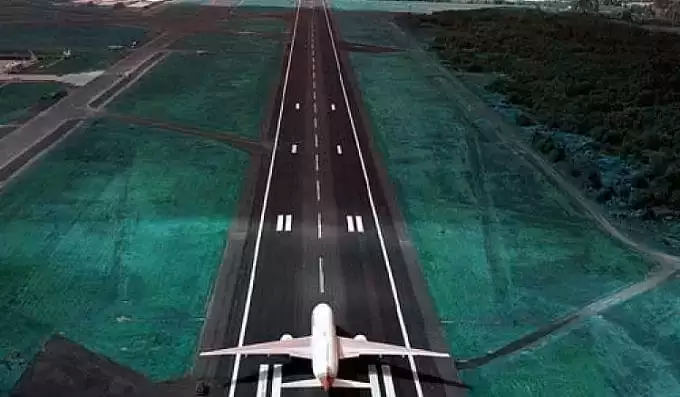

In [2]:
cv2.imread("/content/airplane.png")

In [6]:
# Solution
# todo: canny detection and display
def edge_detection(imagepath, threshold1, threshold2, apertureSize):
  image = cv2.imread(imagepath)
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  edges = cv2.Canny(gray, threshold1, threshold2, apertureSize=apertureSize)
  return edges



array([[  0,   0,   0, ..., 255,   0, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ...,   0, 255,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
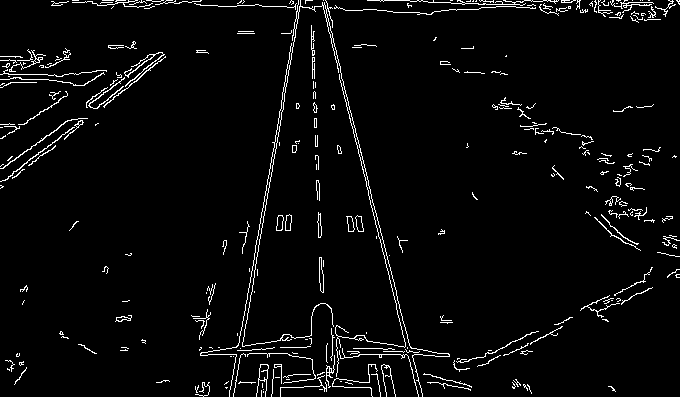

In [5]:
edge_detection("/content/airplane.png", 100, 200, 3)

In [ ]:
# HT implementation
# solution muster, free free to change it
def hough_transformation_line(image, delta_r, delta_phi):
    # line description: x sin(phi) - y cos(phi) + roh = 0, phi \in [0, pi], r \in [-r_max, r_max]
    # imag.shape: [H, B], binary image
    # delta_phi: in rad

    # todo: discritize phi in [0, np.pi] by using delta_phi
    phi_s = .... # a list of phi after discritization

    # todo: estimate r_max
    # todo: discritize r in [-r_max, +r_max] by using delta_r
    rho_s = .... # a list of r after discritization

    # todo: initialize an accumulator by the lengthes of rho_s and phi_s with zeros

    # todo: update the accumulator by +1 for every non-zero points in image
    for x, y in image's non-zero points:
      for phi_index,  phi in enumerate(phi_s):
        rho_index = ...
        accumulator[phi_index, rho_index] += 1

    return accumulator

# todo: compute accumulator and visualize it in the correct way (normalization!)




In [ ]:
# Find local maxima of the computed accumulator, e.g. mannually
# Convert local maxima back to the image space and display the detected lines